
# Trabajo Práctico: procesamiento de archivos PDF

- **Materia:** Procesamiento del habla
- **Profesor:** Ana Laura Diedrichs
- **Alumno:** Augusto Presfraind  
- **Fecha:** 14/4/2026

## Introducción

Este es del proyecto que corresponde al primer trabajo practico obligatorio de Procesamiento del habla





## 0. Instalación e importación de librerías

En Google Colab conviene instalar primero las librerías necesarias para asegurar que el notebook se ejecute sin problemas.


In [23]:

# Esta celda instala las librerías necesarias tanto en Jupyter como en Colab.
%pip install pymupdf pdfplumber nltk requests pandas matplotlib -q


Note: you may need to restart the kernel to use updated packages.


In [37]:

import requests
from pathlib import Path
import re

import fitz   # PyMuPDF
import pdfplumber
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.tokenize import wordpunct_tokenize
from nltk.corpus import stopwords
from collections import Counter
import string



## 1. Adquisición y metadatos

En esta primera parte se descarga el PDF y luego se inspeccionan sus metadatos.  
El documento elegido es un reporte público de la **Organización Mundial de la Salud (WHO)** sobre la implementación del Convenio Marco para el Control del Tabaco.

Este PDF fue elegido porque:
- es público y accesible desde la web,
- contiene texto narrativo,
- tiene metadatos embebidos,
- incluye páginas con tablas que permiten cubrir toda la consigna.



### Paso 1: Descargar el PDF desde una URL pública


In [ ]:

pdf_url = "https://fctc.who.int/docs/librariesprovider12/meeting-reports/2025-global-progress-report-on-implementation-of-the-who-fctc.pdf?download=true&sfvrsn=8a0d2f8_2"
pdf_path = Path("who_fctc_2025_report.pdf")

if not pdf_path.exists():
    response = requests.get(pdf_url, stream=True)
    response.raise_for_status()
    pdf_path.write_bytes(response.content)
    print("PDF descargado correctamente")
else:
    print("PDF ya disponible localmente")

print("Archivo guardado como:", pdf_path.resolve())


PDF ya disponible localmente
Archivo guardado como: C:\Users\augus\Desktop\Ciencia de datos\Procesamiento del habla\who_fctc_2025_report.pdf



### Paso 2: Abrir el PDF y revisar sus metadatos


In [26]:

doc = fitz.open(pdf_path)

metadata = doc.metadata
num_pages = doc.page_count

print("Metadatos completos del PDF:")
print(metadata)

print("\nResumen de metadatos relevantes")
print("-" * 40)
print("Título:", metadata.get("title"))
print("Autor:", metadata.get("author"))
print("Creator:", metadata.get("creator"))
print("Producer:", metadata.get("producer"))
print("Cantidad de páginas:", num_pages)


Metadatos completos del PDF:
{'format': 'PDF 1.7', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'creator': 'Adobe InDesign 21.0 (Macintosh)', 'producer': 'Adobe PDF Library 18.0', 'creationDate': 'D:20251216094856Z', 'modDate': 'D:20251216094904Z', 'trapped': '', 'encryption': None}

Resumen de metadatos relevantes
----------------------------------------
Título: 
Autor: 
Creator: Adobe InDesign 21.0 (Macintosh)
Producer: Adobe PDF Library 18.0
Cantidad de páginas: 184



### Análisis de metadatos

El análisis de metadatos permite conocer información técnica del archivo antes de procesarlo a fondo.  
En este documento se puede observar que el PDF sí contiene metadatos embebidos, algo útil porque no todos los archivos PDF traen autor, título o software de creación bien cargados.

La cantidad de páginas también sirve para dimensionar el tamaño del documento y decidir qué páginas conviene inspeccionar para texto narrativo o tablas.



## 2. Análisis estructural del texto

Ahora se extrae el texto completo de las primeras 5 páginas.  
La función elegida es:

```python
page.get_text("text")
```

Esta función devuelve el texto de forma bastante cruda, conservando muchos saltos de línea y parte de la estructura visual interpretada por la librería.



### Paso 1: Extraer el texto de las primeras 5 páginas


In [27]:

raw_pages = []

for i in range(5):
    page = doc.load_page(i)
    raw_text = page.get_text("text")
    raw_pages.append(raw_text)

    print(f"\n{'='*70}")
    print(f"PÁGINA {i+1}")
    print(f"{'='*70}\n")
    print(repr(raw_text[:2500]))



PÁGINA 1

'2025 Global Progress Report\non Implementation of the\nWHO Framework Convention  \non Tobacco Control\n2025\n'

PÁGINA 2

''

PÁGINA 3

'2025 Global Progress Report\non Implementation of the\nWHO Framework Convention  \non Tobacco Control\n'

PÁGINA 4

'2025 Global Progress Report on Implementation of the WHO Framework Convention on Tobacco Control\n© World Health Organization 2025 (acting as the host organization for the Secretariat of the WHO \nFramework Convention on Tobacco Control & its Protocols (Convention Secretariat)).\nSome rights reserved. This work is available under the Creative Commons Attribution-NonCommercial-\nShareAlike 3.0 IGO licence (CC BY-NC-SA 3.0 IGO; https://creativecommons.org/licenses/by-nc-sa/3.0/igo). \nUnder the terms of this licence, you may copy, redistribute and adapt the work for non-commercial \npurposes, provided the work is appropriately cited, as indicated below. In any use of this work, there should \nbe no suggestion that WHO endorses


### Paso 2: Elegir una muestra y analizar los separadores

Para identificar los caracteres especiales conviene trabajar con `repr()`, porque así se ven explícitamente los caracteres invisibles como `\n`, `\r` o `\t`.


In [28]:

# Elegimos la primera página entre las primeras cinco que tenga texto suficiente
sample_text = next((txt for txt in raw_pages if txt and txt.strip()), raw_pages[0])

print("Fragmento de muestra:")
print(repr(sample_text[:1500]))

special_chars = {
    "salto_linea": sample_text.count("\n"),
    "retorno_carro": sample_text.count("\r"), 
    "sangría": sample_text.count("\t"),
    "doble_espacio": sample_text.count("  "),
}

print("\nConteo de separadores detectados:")
print(special_chars)


Fragmento de muestra:
'2025 Global Progress Report\non Implementation of the\nWHO Framework Convention  \non Tobacco Control\n2025\n'

Conteo de separadores detectados:
{'salto_linea': 5, 'retorno_carro': 0, 'sangría': 0, 'doble_espacio': 1}



### Análisis estructural

A partir de la extracción cruda se observa que el principal carácter separador es `\n`, es decir, el salto de línea.

Esto indica que los párrafos y bloques del documento no están organizados como texto continuo, sino como líneas separadas según la maquetación original del PDF.  
En cambio, `\r` y `\t` no suelen tener un papel importante en este archivo.

También puede haber múltiples espacios o cortes visuales entre bloques, pero el separador dominante sigue siendo el salto de línea.

En términos de estructura:
- los títulos suelen aparecer aislados,
- algunos bloques están segmentados por líneas cortas,
- la organización responde más al diseño visual del PDF que a una estructura limpia pensada para NLP.


## 3. Extracción de datos tabulares

La consigna pide localizar una página con tabla, extraerla y convertirla en un `DataFrame`.

En este PDF se eligió una página con una tabla textual del reporte.  
Como suele pasar con muchos PDF, la tabla puede no estar almacenada internamente como una tabla real, sino como texto alineado visualmente.

Por eso voy a mostrar dos enfoques:

1. **Intento 1:** extracción automática con `extract_table()`
2. **Intento 2:** reconstrucción manual a partir del texto extraído



### Paso 1: Intento de extracción automática


In [29]:

table_page_index = 30  # página 31 del documento si contamos desde 1

with pdfplumber.open(pdf_path) as pdf:
    page = pdf.pages[table_page_index]
    extracted_table = page.extract_table()
    page_text = page.extract_text()

print("Resultado de extract_table():")
print(extracted_table)

print("\nPrimer fragmento del texto de la página:")
print(page_text[:2500] if page_text else "No se pudo extraer texto de la página.")


Resultado de extract_table():
[['', 'Deaths (million)', 'YLL (million)', 'YLD (million)', 'DALY (million)']]

Primer fragmento del texto de la página:
Prevalence of tobacco use and tobacco-related mortality 12
Complementary information from the Global Burden of Disease study
The Global Burden of Disease (GBD) study is the most extensive effort to measure health
loss across more than 190 countries.9 It measures deaths, years of life lost (YLL), years
lived with disability (YLD) and disability-adjusted life years (DALY) attributable to tobacco
use and exposure to second-hand smoke.
Tobacco use is classified as a Level 2 behavioural risk and includes various forms of
smoking (cigarettes, cigars, pipes, bidis, kreteks and waterpipes), smokeless tobacco
products (e.g. chewing tobacco, snuff, snus, gutka and paan with tobacco), and exposure
to second-hand smoke.
Health outcomes of tobacco use in different forms and exposure to second-hand tobacco
smoke have been studied as part of the GBD. T


### Observación

Si `extract_table()` devuelve `None` o una estructura incompleta, eso no significa que no exista una tabla en la página.

Muchas veces la tabla está "dibujada" visualmente dentro del PDF, pero no almacenada como un objeto tabular claro. En esos casos hace falta reconstruirla a partir del texto.



### Paso 2: Reconstrucción manual de la tabla desde el texto


In [30]:

# Buscamos filas simples dentro del texto de la página
# En esta tabla aparecen líneas con una etiqueta y cuatro métricas numéricas.
lines = page_text.split("\n") if page_text else []

pattern = re.compile(r"^(Total|Female|Male)\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)$")

rows = []
for line in lines:
    match = pattern.match(line.strip())
    if match:
        rows.append(match.groups())

df_table = pd.DataFrame(
    rows,
    columns=["Group", "Deaths", "YLL", "YLD", "DALYs"]
)

df_table


,Group,Deaths,YLL,YLD,DALYs
0,Total,7.25,168,26.30,195
1,Female,1.57,33.7,8.31,42
2,Male,5.68,135,18,156



### Paso 3: Limpieza básica de la tabla


In [31]:

# Convertimos las columnas numéricas
for col in ["Deaths", "YLL", "YLD", "DALYs"]:
    df_table[col] = pd.to_numeric(df_table[col], errors="coerce")

# Eliminamos filas completamente vacías si existieran
df_table = df_table.dropna(how="all").reset_index(drop=True)

print(df_table.info())
print("\nTabla final:")
display(df_table)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Group   3 non-null      object 
 1   Deaths  3 non-null      float64
 2   YLL     3 non-null      float64
 3   YLD     3 non-null      float64
 4   DALYs   3 non-null      int64  
dtypes: float64(3), int64(1), object(1)
memory usage: 252.0+ bytes
None

Tabla final:


,Group,Deaths,YLL,YLD,DALYs
0,Total,7.25,168.0,26.30,195
1,Female,1.57,33.7,8.31,42
2,Male,5.68,135.0,18.00,156



### Análisis de la extracción tabular

La extracción automática no siempre resuelve bien las tablas en PDF.  
En este caso fue más confiable reconstruir la estructura a partir del texto.

Después de la limpieza:
- se definieron nombres de columnas claros,
- se convirtieron las métricas a formato numérico,
- se eliminaron posibles filas vacías.

El resultado final ya queda en un formato tabular apto para análisis con Pandas.



## 4. Análisis de frecuencias (NLP básico)

Para esta etapa se toma una página predominantemente narrativa del documento.  
Se eligió una página con texto corrido para evitar mezclar tablas, encabezados técnicos o listados.

Procedimiento:
1. extraer el texto,
2. pasarlo a minúsculas,
3. tokenizar,
4. eliminar stop words y signos de puntuación,
5. calcular frecuencias,
6. visualizar las 15 palabras más frecuentes.



### Paso 1: Extraer texto de una página narrativa


In [32]:

narrative_page_index = 141  # página 142 si contamos desde 1

narrative_text = doc.load_page(narrative_page_index).get_text("text")

print(narrative_text[:2500])


Canada
Settlement of health care cost recovery and class action litigation
In October 2024, a proposed settlement of Can$ 32.5 billion was announced regarding a 
series of lawsuits involving all the Canadian provinces and territories against Canada’s 
three largest tobacco manufacturers and their parent companies (JTI-Macdonald (Japan 
Tobacco International), Rothmans, Benson & Hedges (Philip Morris International), and 
Imperial Tobacco Canada Ltd (British American Tobacco)) for health-related costs 
associated with their products. The settlement was approved by the Ontario Superior 
Court Chief Justice on 6 March 2025. The Federal Government of Canada is not a party to 
this settlement or the settlement negotiations, nor to the lawsuits, which were brought by 
the provinces alongside class actions by individuals.
This settlement also applied to the Conseil québécois sur le tabac et la santé (CQTS)-Blais  
(“CQTS-Blais”) and Létourneau class actions in the province of Quebec. These are


### Paso 2: Inicializar la variable con las palabras que generan ruido en el analisis


In [33]:

try:
    nltk.data.find("corpora/stopwords")
except LookupError:
    nltk.download("stopwords", quiet=True)
stop_words = set(stopwords.words("english"))



### Paso 3: Pasar a minúsculas, tokenizar y limpiar


In [34]:

text_lower = narrative_text.lower()

tokens = wordpunct_tokenize(text_lower)

tokens_limpios = [
    token for token in tokens
    if token not in string.punctuation
    and token.isalpha()
    and token not in stop_words
]

print("Primeros 50 tokens limpios:")
print(tokens_limpios[:50])


Primeros 50 tokens limpios:
['canada', 'settlement', 'health', 'care', 'cost', 'recovery', 'class', 'action', 'litigation', 'october', 'proposed', 'settlement', 'billion', 'announced', 'regarding', 'series', 'lawsuits', 'involving', 'canadian', 'provinces', 'territories', 'canada', 'three', 'largest', 'tobacco', 'manufacturers', 'parent', 'companies', 'jti', 'macdonald', 'japan', 'tobacco', 'international', 'rothmans', 'benson', 'hedges', 'philip', 'morris', 'international', 'imperial', 'tobacco', 'canada', 'ltd', 'british', 'american', 'tobacco', 'health', 'related', 'costs', 'associated']



En esta etapa se eliminaron:
- signos de puntuación,
- números,
- y stop words del inglés, ya que el documento trabajado está escrito en ese idioma.

Se conservan solamente los tokens con mayor carga semántica para el análisis de frecuencias.



### Paso 4: Calcular frecuencias y quedarnos con las 15 palabras más repetidas


In [35]:

frecuencias = Counter(tokens_limpios)
top_15 = frecuencias.most_common(15)

top_15


[('settlement', 11),
 ('tobacco', 11),
 ('class', 9),
 ('cqts', 8),
 ('blais', 8),
 ('canada', 7),
 ('billion', 7),
 ('court', 7),
 ('companies', 6),
 ('actions', 6),
 ('létourneau', 6),
 ('quebec', 6),
 ('provinces', 5),
 ('health', 4),
 ('canadian', 4)]


### Paso 5: Graficar las 15 palabras más frecuentes


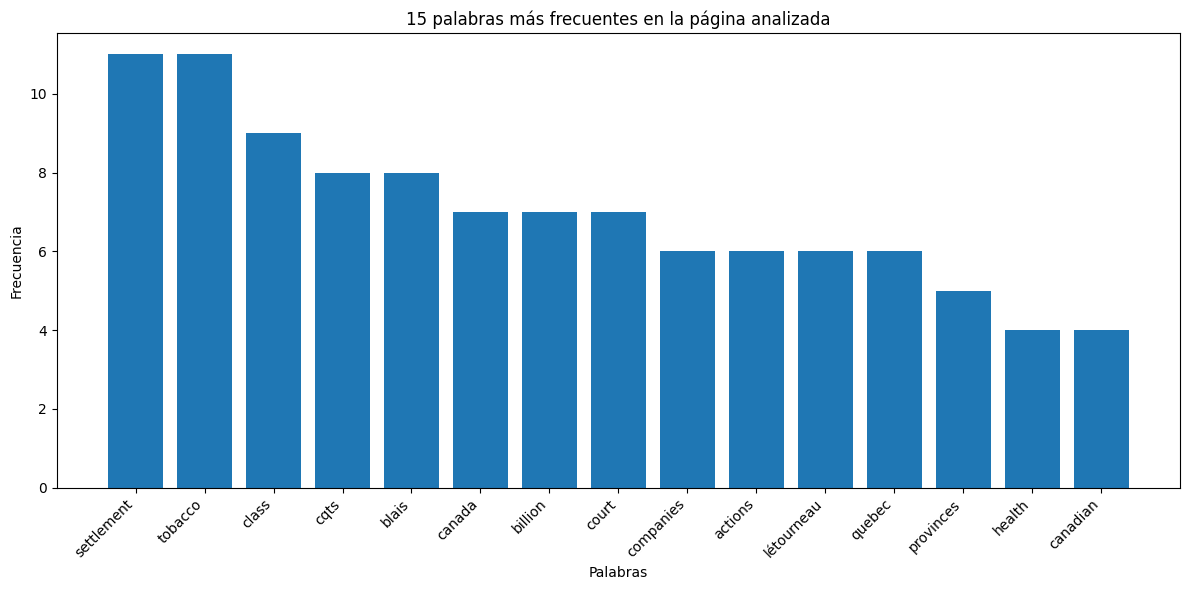

In [36]:

palabras = [palabra for palabra, frecuencia in top_15]
valores = [frecuencia for palabra, frecuencia in top_15]

plt.figure(figsize=(12, 6))
plt.bar(palabras, valores)
plt.xticks(rotation=45, ha="right")
plt.title("15 palabras más frecuentes en la página analizada")
plt.xlabel("Palabras")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()



### Interpretación del gráfico

El gráfico permite detectar rápidamente los términos dominantes en la página seleccionada.  
Como el documento se relaciona con la implementación del convenio de control del tabaco, es lógico que aparezcan palabras vinculadas con objetivos, indicadores, implementación, reportes o partes firmantes.

### ¿Aparecen tokens que también podrían considerarse stop words?

Sí. Aunque no sean stop words estándar del inglés, algunas palabras muy frecuentes del propio documento pueden comportarse como **stop words**.  
Por ejemplo, términos como `who`, `fctc`, `report`, `parties` o `implementation` podrían resultar demasiado generales si el objetivo fuera descubrir temas más específicos dentro del texto.

Esto muestra que en análisis más avanzados no siempre alcanza con usar una lista estándar de stop words: a veces también conviene construir una lista personalizada según el corpus trabajado.



## 5. Conclusión

Este trabajo permitió recorrer un flujo completo de procesamiento documental a partir de un PDF real.

### Lo realizado
- se descargó automáticamente un PDF desde una URL pública,
- se inspeccionaron sus metadatos,
- se extrajo texto crudo de las primeras páginas,
- se analizaron los separadores y la estructura del texto,
- se recuperó una tabla y se la transformó en un `DataFrame`,
- y se aplicó un análisis básico de frecuencias con NLP.

### Lo aprendido

Uno de los aprendizajes más importantes es que un PDF no debe tratarse como si fuera una base de datos limpia.  
Aunque visualmente parezca ordenado, internamente puede guardar el contenido de maneras poco amigables para el análisis automático.

También se comprobó que:
- los metadatos no siempre son completos,
- la extracción de texto suele arrastrar saltos de línea y cortes extraños,
- las tablas no siempre se extraen bien de forma automática,
- y el preprocesamiento es una etapa fundamental antes de cualquier análisis de NLP.

### Dificultades encontradas

La principal dificultad fue la parte tabular, porque el documento no siempre presenta una estructura que `pdfplumber` pueda interpretar directamente como tabla.  
Por eso fue necesario complementar la extracción automática con una reconstrucción manual a partir del texto.

### Referencias

- PDF trabajado: 2025 Global Progress Report on Implementation of the WHO Framework Convention on Tobacco Control.
- Documentación oficial de pdfplumber - https://github.com/jsvine/pdfplumber - https://github.com/jsvine/pdfplumber/blob/stable/examples/notebooks/extract-table-ca-warn-report.ipynb
- Documentación oficial de nltk - https://github.com/ua-datalab/NLP-Speech/blob/main/Text_pre_processing_for_NLP/Text_pre_processing_for_NLP.ipynb
- Documentación oficial de matplotlib
- Videos de apoyo: https://www.youtube.com/watch?v=DSsqzKA_hPg - https://www.youtube.com/watch?v=SNNoWED3ZYI
- Notebook de semana 1: https://github.com/anadiedrichs/procesamientoDelHabla/blob/main/0_archivos_pdf.ipynb